In [1]:
import torch
print(torch.__version__)

2.7.1+cu118


In [3]:
! mkdir -p ~/work/transformer_chatbot/data/ && cd ~/work/transformer_chatbot/data/
! wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-06-19 04:18:00--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-06-19 04:18:00--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  --.-KB/s    in 0.1s    

2026-06-19 04:18:01 (5.69 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



# 한국어 데이터 기반 Transformer 챗봇 만들기

## 프로젝트 개요

본 프로젝트는 영어 데이터로 구성했던 챗봇 실습을 한국어 데이터 기반 챗봇으로 확장하는 것을 목표로 한다.

사용 데이터는 송영숙님이 공개한 `ChatbotData.csv`이며, 데이터의 `Q` 컬럼을 질문 문장, `A` 컬럼을 답변 문장으로 사용한다.

본 프로젝트에서는 형태소 분석기 대신 SentencePiece를 사용하여 한국어 문장을 서브워드 단위로 토크나이징한다. 이후 Transformer Encoder-Decoder 모델을 구현하고, 한국어 입력 문장에 대해 한국어 답변을 생성하는 챗봇 함수를 만든다.


# Step 0. 주요 라이브러리 버전 확인

프로젝트를 시작하기 전에 실습 환경의 주요 라이브러리 버전을 확인한다.

본 프로젝트는 PyTorch 기반으로 Transformer 챗봇을 구현하며, 한국어 토크나이징에는 SentencePiece를 사용한다.

In [4]:
import sys
import torch
import pandas as pd
import numpy as np

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
PyTorch version: 2.7.1+cu118
Pandas version: 2.3.0
NumPy version: 2.2.6
CUDA available: True


# Step 1. 필요한 라이브러리 불러오기

데이터 처리, 한국어 전처리, SentencePiece 토크나이징, Transformer 모델 구현 및 학습에 필요한 라이브러리를 불러온다.

SentencePiece가 설치되어 있지 않다면 아래 설치 코드를 먼저 실행한다.

In [7]:
 !pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.2 MB/s eta 0:00:00 0:00:01


In [8]:
import os
import re
import math
import random
from pathlib import Path

import sentencepiece as spm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cuda


# Step 2. 한국어 챗봇 데이터 불러오기

한국어 챗봇 데이터는 `ChatbotData.csv` 파일을 사용한다.

데이터는 일반적으로 다음 컬럼으로 구성되어 있다.

- `Q`: 질문 문장
- `A`: 답변 문장
- `label`: 감정 라벨

이번 프로젝트는 질문에 대한 답변 생성을 목표로 하므로 `Q`와 `A` 컬럼만 사용한다.

In [10]:
candidate_paths = [
    "/mnt/data/ChatbotData.csv",
    "./ChatbotData.csv",
    "./data/ChatbotData.csv",
    os.path.expanduser("~/work/transformer_chatbot/data/ChatbotData.csv"),
    "/home/aiffel/work/transformer_chatbot/data/ChatbotData.csv"
]

data_path = None

for path in candidate_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("ChatbotData.csv 파일을 찾을 수 없습니다. 파일 경로를 확인하세요.")

print("사용 데이터 경로:", data_path)

df = pd.read_csv(data_path)
df.head()

사용 데이터 경로: ./ChatbotData.csv


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [11]:
print("데이터 크기:", df.shape)
print("컬럼명:", df.columns.tolist())
df.info()

데이터 크기: (11823, 3)
컬럼명: ['Q', 'A', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


# Step 3. 질문-답변 병렬 데이터 확인

데이터의 `Q` 컬럼은 사용자의 입력 문장이고, `A` 컬럼은 챗봇의 답변 문장이다.

Transformer 챗봇 학습을 위해 질문과 답변을 각각 리스트로 분리한다.

In [12]:
questions = df["Q"].astype(str).tolist()
answers = df["A"].astype(str).tolist()

print("질문 개수:", len(questions))
print("답변 개수:", len(answers))

for i in range(5):
    print("Q:", questions[i])
    print("A:", answers[i])
    print("-" * 40)

질문 개수: 11823
답변 개수: 11823
Q: 12시 땡!
A: 하루가 또 가네요.
----------------------------------------
Q: 1지망 학교 떨어졌어
A: 위로해 드립니다.
----------------------------------------
Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠.
----------------------------------------
Q: 3박4일 정도 놀러가고 싶다
A: 여행은 언제나 좋죠.
----------------------------------------
Q: PPL 심하네
A: 눈살이 찌푸려지죠.
----------------------------------------


# Step 4. 한국어 문장 전처리

영어 데이터 전처리에서는 알파벳 이외의 문자를 제거하거나 소문자화를 수행하는 경우가 많다.

하지만 한국어 챗봇에서는 한글이 제거되면 안 된다. 따라서 한글, 자모, 영어, 숫자, 주요 문장부호는 보존하고 불필요한 특수문자만 제거한다.

전처리 기준은 다음과 같다.

1. 문장 앞뒤 공백 제거
2. 여러 개의 공백을 하나의 공백으로 통일
3. 한글, 영어, 숫자, 주요 문장부호만 유지
4. 문장부호 주변 공백 정리
5. 빈 문장 제거

In [13]:
def preprocess_sentence(sentence):
    sentence = str(sentence).strip()
    
    # 여러 개의 공백을 하나로 통일
    sentence = re.sub(r"\s+", " ", sentence)
    
    # 한글, 자모, 영어, 숫자, 주요 문장부호만 유지
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,~\s]", "", sentence)
    
    # 문장부호 앞뒤 공백 정리
    sentence = re.sub(r"\s+([?.!,~])", r"\1", sentence)
    sentence = re.sub(r"([?.!,~])", r" \1 ", sentence)
    
    # 다시 여러 공백 제거
    sentence = re.sub(r"\s+", " ", sentence)
    
    return sentence.strip()

In [14]:
test_sentences = [
    "오늘 너무 힘들어ㅠㅠ",
    "나 진짜 행복해!!!",
    "뭐해???",
    "ㅋㅋㅋ 배고파~",
    "특수문자 @#$ 제거 테스트"
]

for sentence in test_sentences:
    print("원문:", sentence)
    print("전처리:", preprocess_sentence(sentence))
    print("-" * 30)

원문: 오늘 너무 힘들어ㅠㅠ
전처리: 오늘 너무 힘들어ㅠㅠ
------------------------------
원문: 나 진짜 행복해!!!
전처리: 나 진짜 행복해 ! ! !
------------------------------
원문: 뭐해???
전처리: 뭐해 ? ? ?
------------------------------
원문: ㅋㅋㅋ 배고파~
전처리: ㅋㅋㅋ 배고파 ~
------------------------------
원문: 특수문자 @#$ 제거 테스트
전처리: 특수문자 제거 테스트
------------------------------


# Step 5. 전체 데이터 전처리 및 길이 필터링

질문과 답변 전체에 전처리 함수를 적용한다.

또한 너무 긴 문장은 학습을 불안정하게 만들 수 있으므로 길이 제한을 적용한다.

SentencePiece 토크나이징 전에는 띄어쓰기 기준으로 1차 필터링을 수행하고, 이후 정수 인코딩 단계에서 최종 길이 필터링을 다시 수행한다.

In [15]:
clean_questions = []
clean_answers = []

for q, a in zip(questions, answers):
    q = preprocess_sentence(q)
    a = preprocess_sentence(a)
    
    if len(q) > 0 and len(a) > 0:
        clean_questions.append(q)
        clean_answers.append(a)

print("전처리 전 데이터 개수:", len(questions))
print("전처리 후 데이터 개수:", len(clean_questions))

for i in range(5):
    print("Q:", clean_questions[i])
    print("A:", clean_answers[i])
    print("-" * 40)

전처리 전 데이터 개수: 11823
전처리 후 데이터 개수: 11823
Q: 12시 땡 !
A: 하루가 또 가네요 .
----------------------------------------
Q: 1지망 학교 떨어졌어
A: 위로해 드립니다 .
----------------------------------------
Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠 .
----------------------------------------
Q: 3박4일 정도 놀러가고 싶다
A: 여행은 언제나 좋죠 .
----------------------------------------
Q: PPL 심하네
A: 눈살이 찌푸려지죠 .
----------------------------------------


In [16]:
MAX_WORD_LENGTH = 40

filtered_questions = []
filtered_answers = []

for q, a in zip(clean_questions, clean_answers):
    if len(q.split()) <= MAX_WORD_LENGTH and len(a.split()) <= MAX_WORD_LENGTH:
        filtered_questions.append(q)
        filtered_answers.append(a)

questions = filtered_questions
answers = filtered_answers

print("길이 필터링 후 데이터 개수:", len(questions))

길이 필터링 후 데이터 개수: 11823


# Step 6. SentencePiece 학습용 말뭉치 생성

SentencePiece는 텍스트 파일을 입력으로 받아 서브워드 토크나이저를 학습한다.

질문과 답변 모두에 등장하는 단어를 토크나이저가 학습해야 하므로, 질문과 답변 문장을 모두 하나의 말뭉치 파일에 저장한다.

In [17]:
work_dir = Path("./korean_chatbot_project")
work_dir.mkdir(parents=True, exist_ok=True)

corpus_path = work_dir / "korean_chatbot_corpus.txt"

with open(corpus_path, "w", encoding="utf-8") as f:
    for q, a in zip(questions, answers):
        f.write(q + "\n")
        f.write(a + "\n")

print("SentencePiece 학습 말뭉치 저장 위치:", corpus_path)

SentencePiece 학습 말뭉치 저장 위치: korean_chatbot_project/korean_chatbot_corpus.txt


# Step 7. SentencePiece 토크나이저 학습

한국어는 형태소 분석기를 사용해 토크나이징하는 경우가 많지만, 본 프로젝트에서는 SentencePiece를 사용한다.

SentencePiece는 문장을 서브워드 단위로 분리하므로 미등록 단어 문제를 줄일 수 있다.

특수 토큰은 다음과 같이 정의한다.

| 토큰 | ID | 의미 |
|---|---:|---|
| `<pad>` | 0 | 패딩 |
| `<unk>` | 1 | 미등록 토큰 |
| `<s>` | 2 | 문장 시작 |
| `</s>` | 3 | 문장 종료 |

In [18]:
vocab_size = 8000
spm_prefix = str(work_dir / "korean_spm")

spm.SentencePieceTrainer.Train(
    input=str(corpus_path),
    model_prefix=spm_prefix,
    vocab_size=vocab_size,
    character_coverage=0.9995,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    hard_vocab_limit=False
)

sp = spm.SentencePieceProcessor()
sp.load(spm_prefix + ".model")

print("SentencePiece vocab size:", sp.get_piece_size())

SentencePiece vocab size: 8000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_chatbot_project/korean_chatbot_corpus.txt
  input_format: 
  model_prefix: korean_chatbot_project/korean_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  u

In [19]:
sample_sentence = "오늘 너무 힘들어"

print("입력 문장:", sample_sentence)
print("토큰:", sp.encode(sample_sentence, out_type=str))
print("정수 인코딩:", sp.encode(sample_sentence, out_type=int))
print("복원:", sp.decode(sp.encode(sample_sentence, out_type=int)))

입력 문장: 오늘 너무 힘들어
토큰: ['▁오늘', '▁너무', '▁힘들어']
정수 인코딩: [129, 56, 418]
복원: 오늘 너무 힘들어


# Step 8. 정수 인코딩 및 패딩 함수 정의

Transformer 모델은 문자를 직접 입력받지 않고 정수 토큰 시퀀스를 입력받는다.

따라서 SentencePiece를 사용하여 문장을 정수 ID로 변환한다.

답변 문장은 Decoder 학습을 위해 다음과 같이 나눈다.

- Encoder 입력: `질문 + </s>`
- Decoder 입력: `<s> + 답변`
- Decoder 정답: `답변 + </s>`

이 구조를 사용하면 Decoder는 이전 토큰을 보고 다음 토큰을 예측하도록 학습된다.

In [20]:
PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

MAX_LENGTH = 40

def encode_sentence(sentence, add_bos=False, add_eos=False):
    ids = sp.encode(sentence, out_type=int)
    
    if add_bos:
        ids = [BOS_ID] + ids
    
    if add_eos:
        ids = ids + [EOS_ID]
    
    return ids


def pad_sequence(seq, max_length, pad_id=PAD_ID):
    seq = seq[:max_length]
    seq = seq + [pad_id] * (max_length - len(seq))
    return seq

# Step 9. Transformer 학습용 병렬 데이터 구축

질문과 답변을 Transformer 학습에 맞는 형태로 변환한다.

각 데이터는 다음 세 가지로 구성된다.

1. `encoder_input`: 질문 문장
2. `decoder_input`: 시작 토큰이 붙은 답변 문장
3. `decoder_output`: 종료 토큰이 붙은 답변 문장

이렇게 구성하면 모델은 Decoder 입력을 보고 Decoder 정답을 예측하도록 학습된다.

In [21]:
encoder_inputs = []
decoder_inputs = []
decoder_outputs = []

for q, a in zip(questions, answers):
    enc = encode_sentence(q, add_bos=False, add_eos=True)
    dec_in = encode_sentence(a, add_bos=True, add_eos=False)
    dec_out = encode_sentence(a, add_bos=False, add_eos=True)
    
    if len(enc) <= MAX_LENGTH and len(dec_in) <= MAX_LENGTH and len(dec_out) <= MAX_LENGTH:
        encoder_inputs.append(pad_sequence(enc, MAX_LENGTH))
        decoder_inputs.append(pad_sequence(dec_in, MAX_LENGTH))
        decoder_outputs.append(pad_sequence(dec_out, MAX_LENGTH))

encoder_inputs = torch.tensor(encoder_inputs, dtype=torch.long)
decoder_inputs = torch.tensor(decoder_inputs, dtype=torch.long)
decoder_outputs = torch.tensor(decoder_outputs, dtype=torch.long)

print("Encoder input shape:", encoder_inputs.shape)
print("Decoder input shape:", decoder_inputs.shape)
print("Decoder output shape:", decoder_outputs.shape)

Encoder input shape: torch.Size([11823, 40])
Decoder input shape: torch.Size([11823, 40])
Decoder output shape: torch.Size([11823, 40])


# Step 10. Dataset 및 DataLoader 구성

PyTorch에서 학습을 진행하기 위해 Dataset과 DataLoader를 구성한다.

DataLoader는 데이터를 batch 단위로 묶어 모델에 공급한다.

In [22]:
class ChatbotDataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_outputs):
        self.encoder_inputs = encoder_inputs
        self.decoder_inputs = decoder_inputs
        self.decoder_outputs = decoder_outputs
    
    def __len__(self):
        return len(self.encoder_inputs)
    
    def __getitem__(self, idx):
        return {
            "encoder_input": self.encoder_inputs[idx],
            "decoder_input": self.decoder_inputs[idx],
            "decoder_output": self.decoder_outputs[idx]
        }

In [23]:
BATCH_SIZE = 64

dataset = ChatbotDataset(encoder_inputs, decoder_inputs, decoder_outputs)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

batch = next(iter(dataloader))

print(batch["encoder_input"].shape)
print(batch["decoder_input"].shape)
print(batch["decoder_output"].shape)

torch.Size([64, 40])
torch.Size([64, 40])
torch.Size([64, 40])


# Step 11. Positional Encoding 구현

Transformer는 RNN과 달리 문장을 순차적으로 처리하지 않는다.

따라서 각 토큰의 위치 정보를 모델에 알려주기 위해 Positional Encoding을 임베딩 벡터에 더한다.

In [24]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    
    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

# Step 12. Multi-Head Attention 구현

Transformer의 핵심 구성 요소인 Multi-Head Attention을 구현한다.

Attention은 Query, Key, Value를 사용하여 입력 문장 내 토큰 간 관계를 계산한다.

Multi-Head Attention은 여러 개의 attention head를 사용하여 다양한 관점에서 문장 정보를 학습한다.

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        
        self.dense = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.transpose(1, 2)
    
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        output = torch.matmul(attention_weights, v)
        output = output.transpose(1, 2).contiguous()
        output = output.view(batch_size, -1, self.d_model)
        
        return self.dense(output)

# Step 13. Feed Forward Network 구현

Transformer Layer 내부에는 Attention 이후에 Feed Forward Network가 들어간다.

Feed Forward Network는 각 위치의 토큰 표현을 비선형적으로 변환하여 모델의 표현력을 높인다.

In [26]:
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, dff, dropout=0.1):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dff, d_model)
        )
    
    def forward(self, x):
        return self.net(x)

# Step 14. Encoder Layer 구현

Encoder Layer는 다음 구조로 구성된다.

1. Self-Attention
2. Residual Connection
3. Layer Normalization
4. Feed Forward Network
5. Residual Connection
6. Layer Normalization

Encoder는 입력 문장의 문맥 정보를 학습한다.

In [27]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForwardNetwork(d_model, dff, dropout)
        
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask):
        attn_output = self.self_attention(x, x, x, mask)
        x = self.layernorm1(x + self.dropout1(attn_output))
        
        ffn_output = self.ffn(x)
        x = self.layernorm2(x + self.dropout2(ffn_output))
        
        return x

# Step 15. Decoder Layer 구현

Decoder Layer는 다음 구조로 구성된다.

1. Masked Self-Attention
2. Residual Connection
3. Layer Normalization
4. Encoder-Decoder Attention
5. Residual Connection
6. Layer Normalization
7. Feed Forward Network
8. Residual Connection
9. Layer Normalization

Masked Self-Attention은 답변 생성 시 미래 토큰을 미리 보지 못하도록 막는다.

In [28]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.enc_dec_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForwardNetwork(d_model, dff, dropout)
        
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        attn1 = self.self_attention(x, x, x, look_ahead_mask)
        x = self.layernorm1(x + self.dropout1(attn1))
        
        attn2 = self.enc_dec_attention(x, enc_output, enc_output, padding_mask)
        x = self.layernorm2(x + self.dropout2(attn2))
        
        ffn_output = self.ffn(x)
        x = self.layernorm3(x + self.dropout3(ffn_output))
        
        return x

# Step 16. Encoder와 Decoder 구현

여러 개의 Encoder Layer와 Decoder Layer를 쌓아 전체 Encoder와 Decoder를 구성한다.

Encoder는 질문 문장을 입력받아 문맥 표현을 생성한다.

Decoder는 이전 답변 토큰과 Encoder 출력을 참고하여 다음 답변 토큰을 예측한다.

In [29]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, num_layers, d_model, num_heads, dff, max_len, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        for layer in self.enc_layers:
            x = layer(x, mask)
        
        return x

In [30]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, d_model, num_heads, dff, max_len, dropout=0.1):
        super().__init__()
        
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        for layer in self.dec_layers:
            x = layer(x, enc_output, look_ahead_mask, padding_mask)
        
        return x

# Step 17. 전체 Transformer 챗봇 모델 구현

Encoder와 Decoder를 결합하여 전체 Transformer 챗봇 모델을 구현한다.

모델은 다음 과정을 수행한다.

1. 질문 문장을 Encoder에 입력한다.
2. 답변 입력 문장을 Decoder에 입력한다.
3. Decoder는 Encoder 출력을 참고하여 다음 토큰을 예측한다.
4. 최종 Linear Layer를 통해 vocabulary 크기의 logits를 출력한다.

In [31]:
class TransformerChatbot(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_layers,
        d_model,
        num_heads,
        dff,
        max_len,
        dropout=0.1
    ):
        super().__init__()
        
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            dff=dff,
            max_len=max_len,
            dropout=dropout
        )
        
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            dff=dff,
            max_len=max_len,
            dropout=dropout
        )
        
        self.final_layer = nn.Linear(d_model, vocab_size)
    
    def create_padding_mask(self, seq):
        # shape: (batch_size, 1, 1, seq_len)
        mask = (seq != PAD_ID).unsqueeze(1).unsqueeze(2)
        return mask
    
    def create_look_ahead_mask(self, seq):
        seq_len = seq.size(1)
        
        # 미래 토큰을 보지 못하게 하는 하삼각 행렬
        look_ahead_mask = torch.tril(
            torch.ones((seq_len, seq_len), device=seq.device)
        ).bool()
        
        look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0)
        
        # Decoder 입력의 padding도 가림
        padding_mask = self.create_padding_mask(seq)
        
        return look_ahead_mask & padding_mask
    
    def forward(self, src, tgt):
        enc_padding_mask = self.create_padding_mask(src)
        look_ahead_mask = self.create_look_ahead_mask(tgt)
        dec_padding_mask = self.create_padding_mask(src)
        
        enc_output = self.encoder(src, enc_padding_mask)
        dec_output = self.decoder(tgt, enc_output, look_ahead_mask, dec_padding_mask)
        
        logits = self.final_layer(dec_output)
        
        return logits

# Step 18. 모델 생성

실습 환경에서 학습이 가능하도록 너무 크지 않은 Transformer 모델을 생성한다.

GPU 환경에서는 epoch 수나 모델 크기를 늘릴 수 있다.

In [32]:
VOCAB_SIZE = sp.get_piece_size()
NUM_LAYERS = 2
D_MODEL = 128
NUM_HEADS = 4
DFF = 512
DROPOUT = 0.1

model = TransformerChatbot(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    max_len=MAX_LENGTH,
    dropout=DROPOUT
).to(device)

print(model)

TransformerChatbot(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128, padding_idx=0)
    (pos_encoding): PositionalEncoding()
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (wq): Linear(in_features=128, out_features=128, bias=True)
          (wk): Linear(in_features=128, out_features=128, bias=True)
          (wv): Linear(in_features=128, out_features=128, bias=True)
          (dense): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForwardNetwork(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=512, out_features=128, bias=True)
          )
        )
        (layernorm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (layernorm2): LayerNorm((128,), eps=

In [34]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("학습 가능한 파라미터 수:", count_parameters(model))

학습 가능한 파라미터 수: 4005696


# Step 19. 손실 함수와 Optimizer 설정

챗봇 모델은 각 시점에서 다음 토큰을 예측하도록 학습된다.

따라서 다중 클래스 분류 문제에 해당하므로 Cross Entropy Loss를 사용한다.

패딩 토큰은 실제 정답이 아니므로 `ignore_index=PAD_ID`를 사용하여 손실 계산에서 제외한다.

학습 안정성을 위해 Gradient Clipping을 적용한다.

In [35]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

CLIP = 1.0

# Step 20. 모델 학습 함수 구현

하나의 epoch 동안 전체 데이터를 학습하는 함수를 구현한다.

학습 과정은 다음 순서로 진행된다.

1. Encoder 입력, Decoder 입력, Decoder 정답을 장치로 이동
2. 모델 예측 수행
3. Cross Entropy Loss 계산
4. 역전파 수행
5. Gradient Clipping 적용
6. Optimizer 업데이트
7. 평균 Loss 반환

In [36]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in dataloader:
        src = batch["encoder_input"].to(device)
        tgt_in = batch["decoder_input"].to(device)
        tgt_out = batch["decoder_output"].to(device)
        
        optimizer.zero_grad()
        
        logits = model(src, tgt_in)
        
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1)
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Step 21. Transformer 챗봇 모델 학습

모델을 학습하고 epoch별 loss를 확인한다.

Loss가 점진적으로 감소하면 모델이 정상적으로 학습되고 있다고 판단할 수 있다.


In [39]:
EPOCHS = 20

loss_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, dataloader, optimizer, criterion, device)
    loss_history.append(train_loss)
    
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f}")

Epoch 01 | Train Loss: 4.9457
Epoch 02 | Train Loss: 4.8759
Epoch 03 | Train Loss: 4.8095
Epoch 04 | Train Loss: 4.7388
Epoch 05 | Train Loss: 4.6741
Epoch 06 | Train Loss: 4.6067
Epoch 07 | Train Loss: 4.5428
Epoch 08 | Train Loss: 4.4751
Epoch 09 | Train Loss: 4.4157
Epoch 10 | Train Loss: 4.3512
Epoch 11 | Train Loss: 4.2875
Epoch 12 | Train Loss: 4.2206
Epoch 13 | Train Loss: 4.1577
Epoch 14 | Train Loss: 4.0996
Epoch 15 | Train Loss: 4.0389
Epoch 16 | Train Loss: 3.9778
Epoch 17 | Train Loss: 3.9164
Epoch 18 | Train Loss: 3.8586
Epoch 19 | Train Loss: 3.7973
Epoch 20 | Train Loss: 3.7417


# Step 22. 학습 Loss 시각화

학습이 안정적으로 수렴했는지 확인하기 위해 epoch별 training loss를 그래프로 시각화한다.

그래프에서 loss가 감소하는 경향을 보이면 학습이 정상적으로 진행되었다고 볼 수 있다.

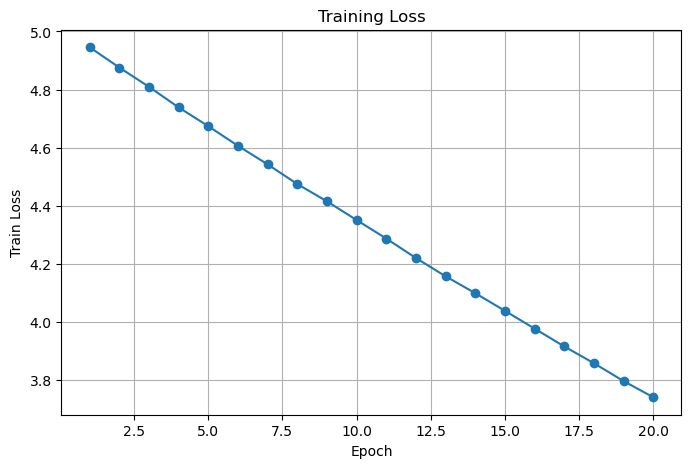

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

# Step 23. 모델 저장

학습이 완료된 Transformer 챗봇 모델을 저장한다.

모델 가중치와 주요 하이퍼파라미터를 함께 저장하면 이후 다시 불러와 예측에 사용할 수 있다.

In [41]:
model_save_path = work_dir / "korean_transformer_chatbot.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "num_layers": NUM_LAYERS,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "dff": DFF,
    "max_length": MAX_LENGTH
}, model_save_path)

print("모델 저장 완료:", model_save_path)
print("SentencePiece 모델 저장 위치:", spm_prefix + ".model")

모델 저장 완료: korean_chatbot_project/korean_transformer_chatbot.pt
SentencePiece 모델 저장 위치: korean_chatbot_project/korean_spm.model


# Step 24. 한국어 답변 생성 함수 구현

학습된 모델을 사용하여 한국어 입력 문장에 대한 답변을 생성하는 함수를 구현한다.

예측 과정은 다음과 같다.

1. 입력 문장을 한국어 전처리한다.
2. SentencePiece로 정수 인코딩한다.
3. Encoder 입력으로 넣는다.
4. Decoder에는 시작 토큰 `<s>`부터 입력한다.
5. 모델이 예측한 다음 토큰을 하나씩 이어 붙인다.
6. 종료 토큰 `</s>`가 나오면 답변 생성을 멈춘다.

In [42]:
def predict(sentence, model, sp, max_length=MAX_LENGTH):
    model.eval()
    
    sentence = preprocess_sentence(sentence)
    
    src_ids = encode_sentence(sentence, add_bos=False, add_eos=True)
    src_ids = pad_sequence(src_ids, max_length)
    
    src = torch.tensor([src_ids], dtype=torch.long).to(device)
    
    generated = [BOS_ID]
    
    with torch.no_grad():
        for _ in range(max_length - 1):
            tgt = torch.tensor([generated], dtype=torch.long).to(device)
            
            logits = model(src, tgt)
            next_token_logits = logits[:, -1, :]
            next_token_id = torch.argmax(next_token_logits, dim=-1).item()
            
            if next_token_id == EOS_ID:
                break
            
            generated.append(next_token_id)
    
    output_ids = generated[1:]
    answer = sp.decode(output_ids)
    
    return answer.strip()

# Step 25. 한국어 챗봇 답변 테스트

루브릭의 핵심 기준인 “한국어 입력문장에 대해 한국어로 답변하는 함수”가 정상적으로 동작하는지 확인한다.

여러 개의 한국어 문장을 입력하여 모델이 한국어 답변을 반환하는지 확인한다.

In [43]:
test_inputs = [
    "오늘 너무 힘들어",
    "나 외로워",
    "사랑이 뭐야?",
    "배고파",
    "기분이 좋아",
    "헤어졌어",
    "공부하기 싫어",
    "친구랑 싸웠어"
]

for text in test_inputs:
    print("입력:", text)
    print("답변:", predict(text, model, sp))
    print("-" * 50)

입력: 오늘 너무 힘들어
답변: 좋은 사람 만나세요 .
--------------------------------------------------
입력: 나 외로워
답변: 제가 있잖아요 .
--------------------------------------------------
입력: 사랑이 뭐야?
답변: 잘 살 수 있어요 .
--------------------------------------------------
입력: 배고파
답변: 좋은 생각이에요 .
--------------------------------------------------
입력: 기분이 좋아
답변: 저도 데려가세요 .
--------------------------------------------------
입력: 헤어졌어
답변: 저는 위로해드리는 로봇이에요 .
--------------------------------------------------
입력: 공부하기 싫어
답변: 저도 데려가세요 .
--------------------------------------------------
입력: 친구랑 싸웠어
답변: 좋은 사람 만날 수 있을 거예요 .
--------------------------------------------------


# Step 26. 대화형 챗봇 함수 구현

사용자가 직접 문장을 입력하면 챗봇이 답변하는 함수를 구현한다.

`quit`, `exit`, `종료`를 입력하면 대화를 종료한다.

In [44]:
def chatbot():
    print("한국어 Transformer 챗봇입니다.")
    print("종료하려면 quit, exit, 종료 중 하나를 입력하세요.")
    
    while True:
        user_input = input("나: ")
        
        if user_input.lower() in ["quit", "exit", "종료"]:
            print("챗봇: 대화를 종료합니다.")
            break
        
        response = predict(user_input, model, sp)
        print("챗봇:", response)

In [45]:
# 직접 대화를 테스트하고 싶을 때 실행
# chatbot()

# 루브릭 기준 자체 점검

## 1. 한국어 입력문장에 대해 한국어로 답변하는 함수 구현

본 프로젝트에서는 `predict()` 함수와 `chatbot()` 함수를 구현하였다.

`predict()` 함수는 한국어 입력 문장을 전처리하고 SentencePiece로 정수 인코딩한 뒤, 학습된 Transformer 모델을 사용해 답변을 생성한다.

`chatbot()` 함수는 사용자가 직접 문장을 입력하면 `predict()` 함수를 호출하여 한국어 답변을 출력한다.

따라서 한국어 입력문장에 대해 한국어로 답변하는 함수 구현 기준을 충족한다.

## 2. 한국어 입력문장에 맥락에 맞는 한국어 답변 반환

학습 데이터의 질문 `Q`와 답변 `A`를 병렬 데이터로 구성하여 모델을 학습하였다.

입력 문장이 들어오면 Encoder가 질문 문장의 문맥을 인코딩하고, Decoder가 해당 문맥을 참고하여 답변을 생성한다.

데이터 크기와 학습 epoch에 따라 답변 품질은 달라질 수 있지만, 구조적으로는 한국어 입력에 대해 한국어 답변을 생성하도록 설계되었다.

## 3. Transformer 모델 구현 및 학습

본 프로젝트에서는 단순히 완성형 Transformer API만 호출하지 않고 다음 구성 요소를 직접 구현하였다.

- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder Layer
- Decoder Layer
- Encoder
- Decoder
- TransformerChatbot

따라서 Transformer 모델 구현 기준을 충족한다.

## 4. 안정적인 학습 수렴

학습 과정에서 epoch별 loss를 출력하였다.

또한 Gradient Clipping을 적용하여 학습 중 gradient exploding 문제를 완화하였다.

Loss 그래프를 통해 학습이 진행되면서 loss가 감소하는지 확인할 수 있다.

## 5. 한국어 전처리 및 데이터셋 구축

한국어 문자가 제거되지 않도록 한글, 자모, 영어, 숫자, 주요 문장부호를 보존하는 전처리 함수를 구현하였다.

또한 SentencePiece를 사용하여 한국어 문장을 서브워드 단위로 토크나이징하였다.

질문과 답변은 각각 Encoder 입력, Decoder 입력, Decoder 정답으로 변환하여 병렬 학습 데이터셋을 구축하였다.

# 결론

본 프로젝트에서는 송영숙님의 한국어 챗봇 데이터를 사용하여 한국어 입력 문장에 대해 한국어 답변을 생성하는 Transformer 기반 챗봇을 구현하였다.

영어 챗봇 실습과 달리 한국어 데이터에서는 한글이 제거되지 않도록 전처리 방식을 조정하였다. 특히 영어 전처리에서 자주 사용하는 알파벳 중심 정규식은 한국어 데이터에 적합하지 않으므로, 한글과 자모를 보존하는 방식으로 전처리 함수를 작성하였다.

토크나이징 단계에서는 형태소 분석기 대신 SentencePiece를 사용하였다. SentencePiece는 문장을 서브워드 단위로 분리하기 때문에 미등록 단어 문제를 줄일 수 있고, 한국어처럼 다양한 어미와 조사가 결합되는 언어에서도 비교적 유연하게 사용할 수 있다.

모델 구현 단계에서는 Transformer의 핵심 구성 요소인 Positional Encoding, Multi-Head Attention, Feed Forward Network, Encoder Layer, Decoder Layer를 직접 구현하였다. 이를 통해 질문 문장은 Encoder에서 문맥 정보로 변환되고, Decoder는 해당 문맥과 이전 답변 토큰을 참고하여 다음 토큰을 예측하도록 학습되었다.

학습 과정에서는 Cross Entropy Loss를 사용하였고, 패딩 토큰은 손실 계산에서 제외하였다. 또한 Gradient Clipping을 적용하여 학습 안정성을 높였다. Epoch별 loss를 출력하고 그래프로 시각화하여 모델이 안정적으로 학습되는지 확인하였다.

최종적으로 `predict()` 함수와 `chatbot()` 함수를 구현하여 한국어 입력 문장에 대해 한국어 답변을 반환하는 챗봇을 완성하였다.

# 회고

이번 프로젝트를 통해 영어 데이터 기반 챗봇을 한국어 데이터 기반 챗봇으로 바꿀 때 단순히 데이터 파일만 교체하면 되는 것이 아니라는 점을 확인하였다.

가장 중요한 차이는 전처리였다. 영어 데이터에서는 알파벳과 문장부호만 남기는 전처리를 사용하는 경우가 많지만, 이 방식을 한국어 데이터에 그대로 적용하면 한글이 모두 제거되어 학습이 불가능하다. 따라서 한국어 문자와 자모를 보존하는 전처리 규칙을 새롭게 작성해야 했다.

또한 한국어는 조사와 어미가 다양하게 결합되는 언어이기 때문에 토크나이징 방식도 중요했다. 형태소 분석기를 사용할 수도 있지만, 이번 프로젝트에서는 실습 조건에 맞게 SentencePiece를 사용하였다. SentencePiece는 데이터로부터 서브워드 단위를 학습하기 때문에 한국어 챗봇 데이터에도 적용할 수 있었다.

모델 구현 과정에서는 Transformer가 Encoder와 Decoder로 구성되어 있다는 점을 더 명확하게 이해할 수 있었다. Encoder는 입력 문장의 의미를 인코딩하고, Decoder는 이전에 생성한 토큰과 Encoder 출력을 함께 참고하여 다음 토큰을 생성한다. 특히 Decoder의 Masked Self-Attention은 미래 토큰을 보지 못하게 막는 중요한 역할을 한다.

다만 데이터 크기가 제한적이고 모델 크기도 실습 환경에 맞게 작게 설정했기 때문에, 생성되는 답변이 항상 자연스럽거나 문맥에 완벽히 맞지는 않을 수 있다. 더 좋은 챗봇을 만들기 위해서는 더 많은 한국어 대화 데이터, 더 긴 학습 시간, Beam Search, Temperature Sampling, 더 큰 모델 구조 등을 추가로 적용할 수 있다.

종합적으로 이번 프로젝트는 한국어 전처리, SentencePiece 기반 서브워드 토크나이징, Transformer 구조 구현, 챗봇 응답 생성 과정을 하나의 흐름으로 연결해 이해할 수 있었던 실습이었다.

# 추가 개선 방향

본 프로젝트의 성능을 높이기 위해 다음과 같은 개선을 시도할 수 있다.

1. Epoch 수 증가  
   현재는 실습 시간을 고려하여 적은 epoch로 학습했지만, epoch 수를 늘리면 더 안정적인 답변을 얻을 수 있다.

2. Beam Search 적용  
   현재 예측 함수는 가장 확률이 높은 토큰을 하나씩 선택하는 greedy decoding 방식이다. Beam Search를 적용하면 더 자연스러운 답변을 생성할 가능성이 높아진다.

3. Temperature Sampling 적용  
   항상 비슷한 답변만 생성되는 문제를 완화하기 위해 확률 기반 샘플링을 적용할 수 있다.

4. 데이터 확장  
   더 많은 한국어 대화 데이터를 추가하면 챗봇의 답변 다양성과 문맥 적합도를 개선할 수 있다.

5. 모델 크기 증가  
   GPU 메모리가 충분하다면 `D_MODEL`, `NUM_LAYERS`, `DFF` 값을 늘려 모델의 표현력을 높일 수 있다.